In [1]:
import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np
from ase import units
from ase.build import fcc111
from ase.calculators.emt import EMT
from ase.constraints import FixAtoms
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, thermalize_momenta

abtem.config.set({"device": "cpu"});
abtem.config.set({"diagnostics.progress_bar": False});

(tutorials:time_resolved)=
# Time-resolved TEM from molecular dynamics

An experimental TEM image is not a snapshot: it is an average over the exposure time. Anything that moves during the
exposure — a diffusing adatom, a fluxional catalyst site, an adsorbate hopping between binding sites — is smeared out,
and the recorded contrast is the time average of the moving structure rather than any of its instantaneous
configurations. Whether a dynamic process is resolved or averaged away therefore depends on how its time scale compares
to the exposure time.

This tutorial shows how to model that averaging in *ab*TEM by combining a molecular dynamics (MD) trajectory with the
multislice algorithm: each MD snapshot is imaged separately, and the resulting intensities are averaged. We use a Cu
adatom diffusing on a Cu(111) surface as the example and compare two limits — a short exposure, in which the adatom is
effectively frozen, and an exposure covering the full trajectory.

This tutorial was contributed by [Gbolagade Olajide](https://github.com/giolajide) and
[Tristan Maxson](https://github.com/tgmaxson), and follows the approach of Olajide et al.
{cite}`olajide_temporal_resolution`.

## Creating the atomic model

We use [ASE](https://ase-lib.org/) to build a Cu(111) slab, fixing the bottom two layers so that they stay in place
during the molecular dynamics, and place a single Cu adatom on the surface.

In [2]:
surface = fcc111("Cu", size=(4, 4, 4), orthogonal=True, vacuum=7)
surface.set_constraint(FixAtoms(mask=[tag in (3, 4) for tag in surface.get_tags()]))

atoms = surface.copy()
adsorption_height = 2.2  # Å above the top layer
atoms += ase.Atoms("Cu", positions=[(5, 5, atoms.positions[:, 2].max() + adsorption_height)])

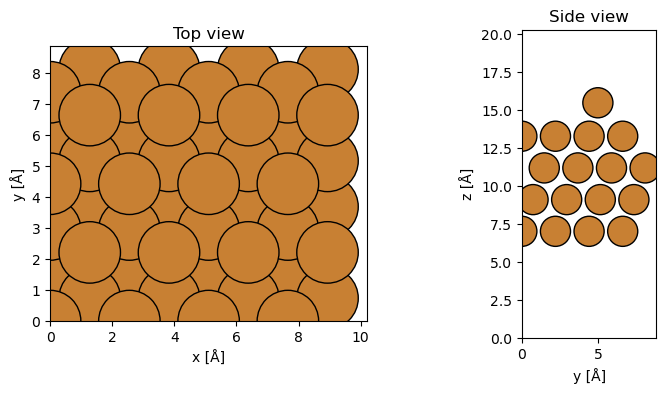

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
abtem.show_atoms(atoms, plane="xy", ax=ax1, title="Top view", tight_limits=True)
abtem.show_atoms(atoms, plane="yz", ax=ax2, title="Side view", tight_limits=True);

### Setting up the imaging geometry

In *ab*TEM the beam always propagates along the $z$-axis, so the model above would be imaged in plan view, looking down
onto the surface. In an *in situ* experiment the interesting sites are usually imaged in profile instead, at the edge of
a particle, so we rotate the [`Atoms`](https://ase-lib.org/ase/atoms.html) object to bring the surface normal into the
image plane. See the [walkthrough on atomic models](walkthrough:atomic_models) for more on orienting a structure.

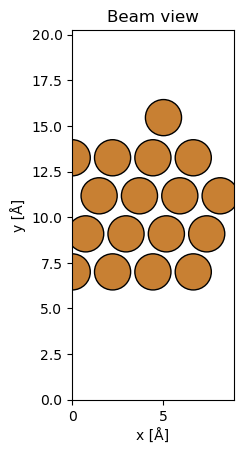

In [4]:
atoms.rotate(-90, "x", rotate_cell=True)
atoms.rotate(-90, "y", rotate_cell=True)

abtem.show_atoms(atoms, plane="xy", title="Beam view", tight_limits=True);

## Running the molecular dynamics

Running MD in ASE requires a [calculator](https://ase-lib.org/ase/calculators/calculators.html) to provide the forces.
The effective medium theory (EMT) potential is parametrized for Cu and is fast enough to run inside this notebook; for a
system EMT does not cover, a machine-learned interatomic potential such as
[MACE-MP-0](https://github.com/ACEsuit/mace-foundations) is a good general-purpose substitute, at a higher cost.

We run Langevin dynamics with a 3 fs timestep at 700 K, a temperature at which the adatom diffuses over the surface
within the 10 ps of simulated time. The trajectory is sampled every 30 steps, giving one snapshot every
90 fs.

In [5]:
temperature = 700  # K, high enough to drive surface diffusion
timestep = 3  # fs
total_time = 10_000  # fs, i.e. 10 ps
sampling_interval = 30  # save every 30th step

steps = int(np.ceil(total_time / timestep))

In [6]:
atoms.calc = EMT()

rng = np.random.default_rng(seed=13)
thermalize_momenta(atoms, temperature, rng=rng)
Stationary(atoms)

trajectory = []

dyn = Langevin(
    atoms,
    timestep=timestep * units.fs,
    temperature_K=temperature,
    friction=0.002,
    fixcm=False,
    rng=rng,
)
dyn.attach(lambda: trajectory.append(atoms.copy()), interval=sampling_interval)
dyn.run(steps)

len(trajectory)

112

```{note}
We keep the trajectory in memory here to avoid writing files, but a realistic workflow runs the dynamics separately and
reads the result back with `ase.io.read("md.traj", ":")`, which gives the same list of `Atoms` objects. The MD is by far
the more expensive part of a time-resolved simulation, so it is worth doing once and reusing.
```

The adatom is the last atom in each snapshot, so we can check directly how far it travelled. It covers several
Ångström over the 10 ps, while the substrate atoms only vibrate around their lattice sites.

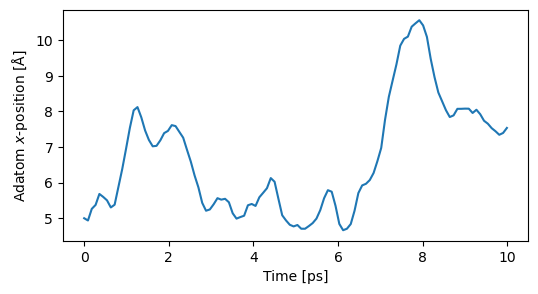

In [7]:
adatom_positions = np.array([image.positions[-1] for image in trajectory])
time = np.arange(len(trajectory)) * sampling_interval * timestep / 1000

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(time, adatom_positions[:, 0])
ax.set_xlabel("Time [ps]")
ax.set_ylabel("Adatom $x$-position [Å]");

The adatom leaves the cell along the way, so we wrap every snapshot back into the cell before building the potentials.

In [8]:
for image in trajectory:
    image.wrap()

## HRTEM simulation

We now simulate HRTEM images in two limiting cases:

1. *Short exposure*: the image is formed from a single MD snapshot. The exposure is long compared to the period of a
   lattice vibration, but too short for the adatom to move appreciably.
2. *Time-averaged*: the image is the average over all snapshots, corresponding to an exposure of 10 ps. This is the
   limit that experimental imaging of a diffusing species approaches.

### Short-exposure image

We take the final snapshot of the trajectory and average over a [frozen phonon](walkthrough:frozen_phonons) ensemble to
include the thermal vibrations that are averaged out even in a short exposure. The two bottom layers are held fixed in
the molecular dynamics, so we give them a vanishing vibration amplitude here as well, keeping the two simulations
comparable.

In [9]:
sigmas = np.where(np.isin(trajectory[-1].get_tags(), (3, 4)), 0, 0.1)  # the fixed layers do not vibrate

static_potential = abtem.Potential(
    abtem.FrozenPhonons(trajectory[-1], num_configs=12, sigmas=sigmas, seed=13),
    sampling=0.05,
    slice_thickness=0.2,
    projection="infinite",
)

The incident beam is represented by a [plane wave](walkthrough:wave_functions) at 200 kV, which we propagate through the
potential with the [multislice algorithm](walkthrough:multislice).

In [10]:
plane_wave = abtem.PlaneWave(energy=200e3)

static_exit_wave = plane_wave.multislice(static_potential)

The exit wave is imaged through an objective lens described by a
[contrast transfer function](walkthrough:contrast_transfer_function). We use an aberration-corrected instrument with a
small negative spherical aberration at Scherzer defocus, and include the focal spread resulting from the chromatic
aberration of the lens and the energy spread of the source, as described in the tutorial on
[partial coherence](tutorials:partial_coherence).

In [11]:
Cs = -8e-6 * 1e10  # spherical aberration of -8 µm, in Å
Cc = 1.0e-3 * 1e10  # chromatic aberration of 1 mm, in Å
energy_spread = 0.3  # standard deviation of the beam energy [eV]

ctf = abtem.CTF(Cs=Cs, energy=plane_wave.energy, defocus="scherzer")
ctf.focal_spread = Cc * energy_spread / plane_wave.energy

In [12]:
static_image = static_exit_wave.apply_ctf(ctf).intensity().mean(0).compute()

```{tip}
The multislice simulation is the expensive step, so it pays to write the result to disk with
`static_image.to_zarr("static_image.zarr")` and read it back later with `abtem.from_zarr("static_image.zarr")`, rather
than recomputing it every time you change the display or the noise level.
```

### Time-averaged image

The time-averaged image is obtained the same way, except that the potential is built from the full list of snapshots
instead of a single one. *ab*TEM turns any sequence of `Atoms` objects into an ensemble of potentials, exactly as it
does for a frozen phonon ensemble, and the exit waves are averaged after the intensity is taken. No frozen phonons are
needed here — the MD trajectory already contains the thermal vibrations.

In [13]:
potential = abtem.Potential(
    trajectory,
    sampling=0.05,
    slice_thickness=0.2,
    projection="infinite",
)

exit_wave = plane_wave.multislice(potential)

time_averaged_image = exit_wave.apply_ctf(ctf).intensity().mean(0).compute()

```{note}
The cost of a time-resolved simulation is the cost of a single image multiplied by the number of snapshots, so it grows
quickly with the exposure time. The snapshots are independent, which makes the calculation trivially parallel — see the
[parallelization walkthrough](walkthrough:parallelization) for running the ensemble across multiple workers, or set
`abtem.config.set({"device": "gpu"})` to run on a GPU.
```

## The effect of time averaging

We compare the two images on a common intensity scale, cropping the field of view to the surface region. The substrate
lattice is imaged identically in both, but the adatom, visible just above the surface in the short-exposure image,
almost disappears when the image is averaged over 10 ps: its intensity is spread over the region it explored during the
exposure instead of being concentrated at a single site.

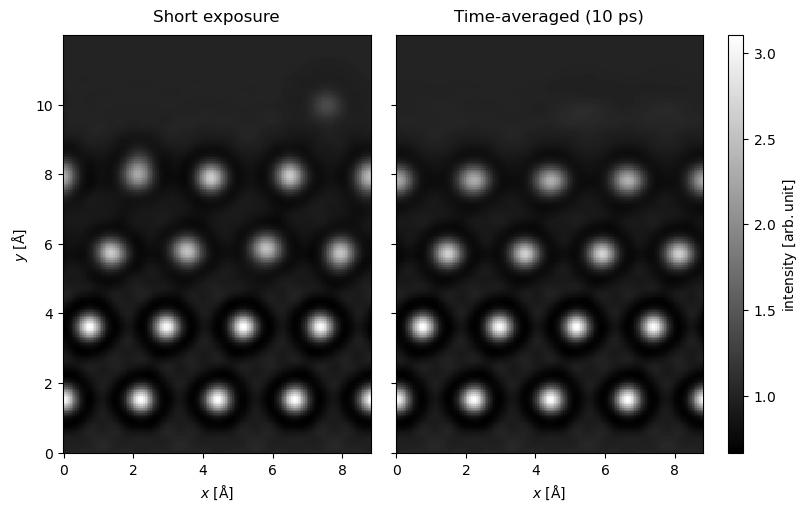

In [14]:
comparison = abtem.stack(
    (static_image, time_averaged_image), ("Short exposure", "Time-averaged (10 ps)")
)
cropped = comparison.crop(extent=(comparison.extent[0], 12), offset=(0, 5.5))

cropped.show(
    explode=True, common_color_scale=True, cmap="gray", figsize=(9, 5), cbar=True
);

The effect is easier to quantify in a line profile taken across the image at the height of the adatom, averaged over a
1 Å wide band. The peak marking the adatom in the short-exposure image is reduced to a broad, low ripple by the time
averaging.

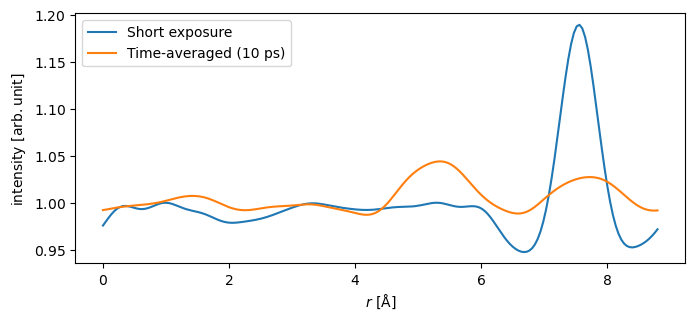

In [15]:
adatom_height = adatom_positions[:, 1].mean()

profiles = comparison.interpolate_line(
    start=(0, adatom_height), end=(comparison.extent[0], adatom_height), width=1, gpts=200
)

profiles.show(figsize=(7, 3), legend=True);

A real image is also limited by the finite number of electrons collected during the exposure, which we include by
applying shot noise for a given dose.

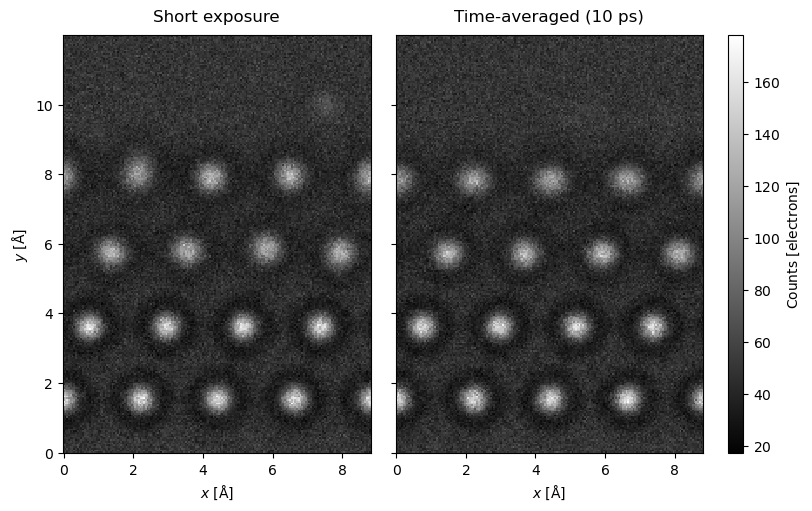

In [16]:
noisy_comparison = cropped.poisson_noise(dose_per_area=2e4, seed=0)

noisy_comparison.show(
    explode=True, common_color_scale=True, cmap="gray", figsize=(9, 5), cbar=True
);

With noise included, the weak time-averaged adatom contrast is no longer distinguishable from the background, while the
same adatom is still visible in the short-exposure image. Averaging over longer times only makes this worse: the adatom
explores a larger region, and its contrast at any single position falls further. This is the basic limitation that
temporal resolution places on the characterization of site dynamics — see Olajide et al.
{cite}`olajide_temporal_resolution` for a detailed analysis of the consequences for *in situ* catalysis studies.